# HEART DISEASE PREDICTION

## BUSINESS PROBLEM STATEMENT

Heart disease is one of the leading causes of death worldwide. Early detection and prediction of heart disease can significantly reduce mortality rates and improve patient outcomes.

Healthcare professionals often rely on medical tests and experience to diagnose heart disease, which can be time-consuming and prone to human error. There is a need for a data-driven system that can assist in predicting the likelihood of heart disease in patients based on clinical and medical attributes

## OBJECTIVE

The main objective of this project is to build a machine learning model that can accurately predict whether a patient has heart disease based on various medical features.

- To analyze patient health data
- To identify key factors affecting heart disease
- To build and compare multiple machine learning models
- To improve model performance using hyperparameter tuning
- To provide insights for early diagnosis

## STEP 1: IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

## STEP 2: LOAD DATA

In [2]:
data = pd.read_csv("values.csv")
labels = pd.read_csv("labels.csv")

In [3]:
# Merge both datasets
df = pd.merge(data, labels, on="patient_id")

In [4]:
print("Shape:", df.shape)
df.head()

Shape: (180, 15)


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


## STEP 3: DATA UNDERSTANDING

In [5]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [6]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [7]:
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [8]:
df.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [9]:
df.tail()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0
179,2nx10r,1,normal,160,3,1,0,0,201,0.0,0,54,163,0,0


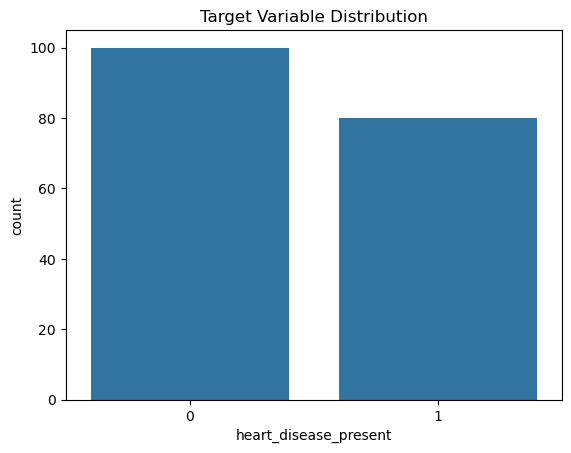

In [10]:
# Target distribution

sns.countplot(x='heart_disease_present', data=df)
plt.title("Target Variable Distribution")
plt.show()

## STEP 4: DATA CLEANING

In [12]:
# Missing values

print(df.isnull().sum())

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64


In [13]:
# Drop unnecessary column

df.drop("patient_id", axis=1, inplace=True)

## STEP 5: ENCODING

In [14]:
le = LabelEncoder()
df['thal'] = le.fit_transform(df['thal'])

## STEP 6: EXPLORATORY DATA ANALYSIS

#### Correlation Heatmap

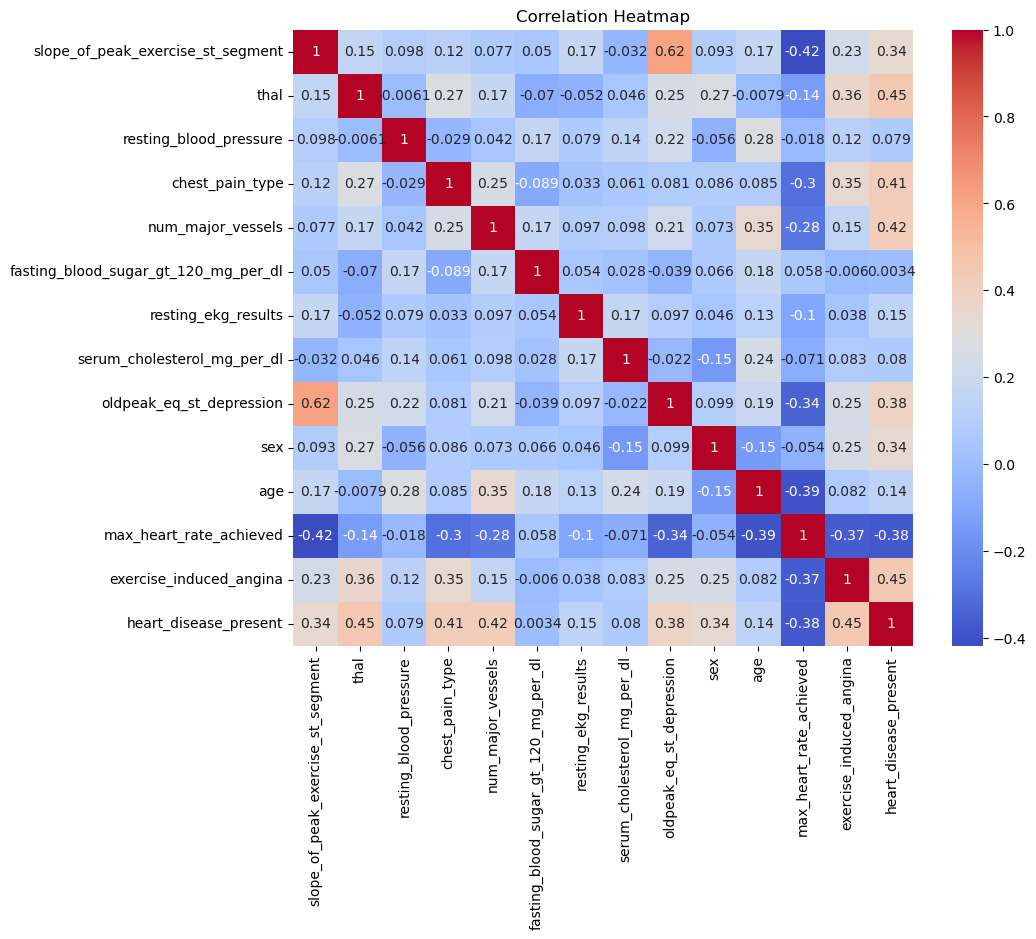

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### Key Insight Graphs

- Age vs Target

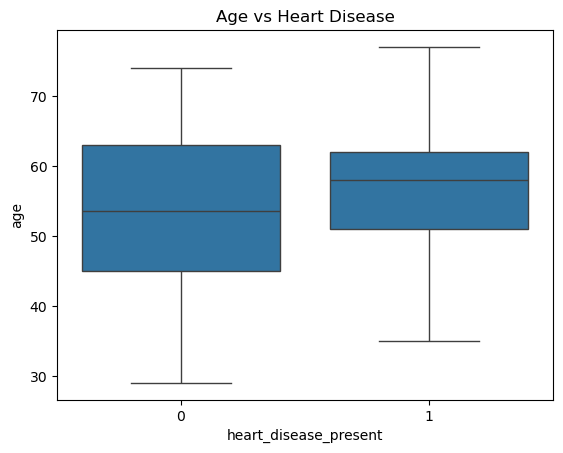

In [17]:
sns.boxplot(x='heart_disease_present', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

- Cholesterol vs Target

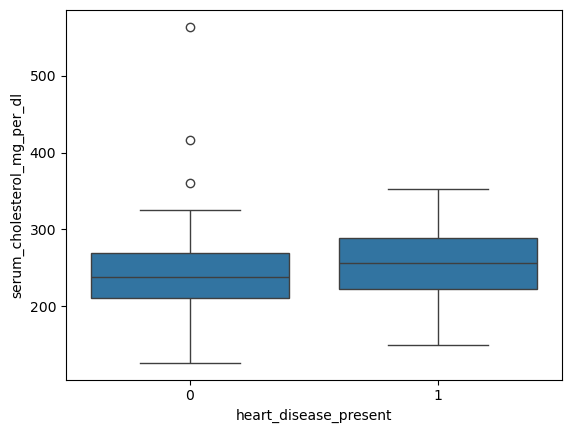

In [18]:
sns.boxplot(x='heart_disease_present', y='serum_cholesterol_mg_per_dl', data=df)
plt.show()

- Gender impact

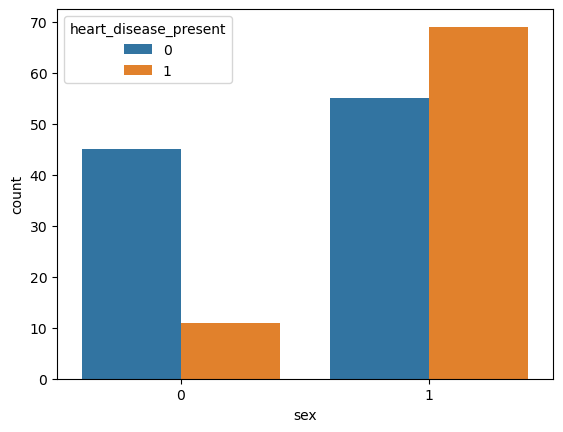

In [21]:
sns.countplot(x='sex', hue='heart_disease_present', data=df)
plt.show()

## STEP 7: FEATURE & TARGET SPLIT

In [20]:
X = df.drop("heart_disease_present", axis=1)
y = df["heart_disease_present"]

## STEP 8: FEATURE SCALING

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## STEP 9: TRAIN-TEST SPLIT

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## STEP 10: MODEL BUILDING

- Logistic Regression

In [24]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

- Random Forest

In [25]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

-  XGBoost

In [26]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

## STEP 11: MODEL EVALUATION

In [27]:
def evaluate(name, y_test, pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))

evaluate("Logistic Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)
evaluate("XGBoost", y_test, xgb_pred)


Logistic Regression
Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.94      0.75      0.83        20

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.83        36
weighted avg       0.85      0.83      0.83        36


Random Forest
Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.94      0.75      0.83        20

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.83        36
weighted avg       0.85      0.83      0.83        36


XGBoost
Accuracy: 0.7777777777777778
              precision    recall  f1-score   support

           0       0.70      0.88      0.78        16
           1       0.88      0.70      0.78        20

    accuracy                           0.78       

## STEP 12: CONFUSION MATRIX

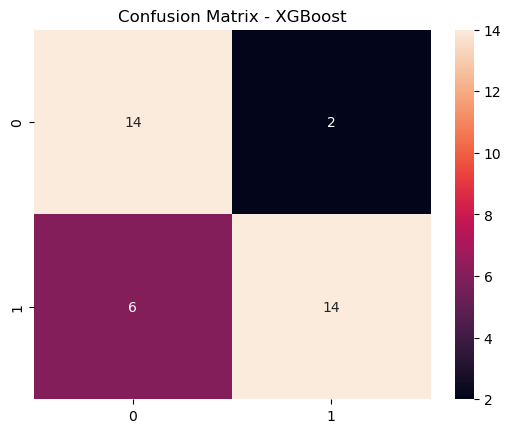

In [28]:
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d')
plt.title("Confusion Matrix - XGBoost")
plt.show()

## STEP 13: ROC CURVE

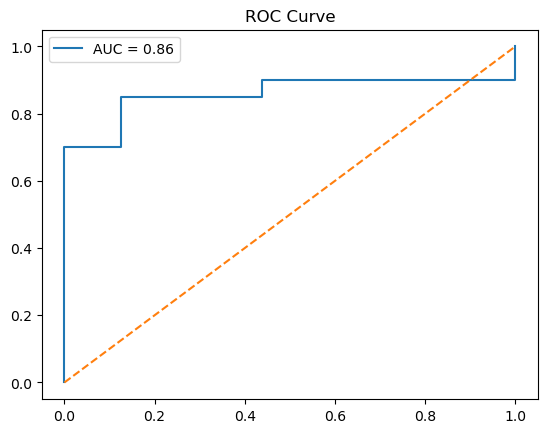

In [29]:
probs = xgb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

## STEP 14: MODEL COMPARISON

In [30]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.833333
1        Random Forest  0.833333
2              XGBoost  0.777778


## STEP 15: HYPERPARAMETER TUNING

In [31]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1]
}

grid = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1}
Best Score: 0.8130541871921183


## STEP 16: FINAL MODEL

In [32]:
best_model = grid.best_estimator_

final_pred = best_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, final_pred))
print(classification_report(y_test, final_pred))

Final Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.78      0.88      0.82        16
           1       0.89      0.80      0.84        20

    accuracy                           0.83        36
   macro avg       0.83      0.84      0.83        36
weighted avg       0.84      0.83      0.83        36



## STEP 17: FINAL CONFUSION MATRIX

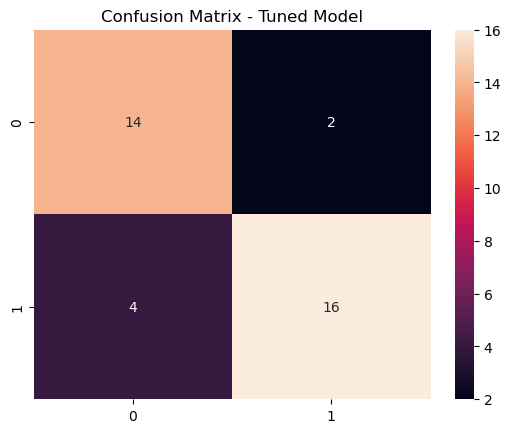

In [33]:
sns.heatmap(confusion_matrix(y_test, final_pred), annot=True, fmt='d')
plt.title("Confusion Matrix - Tuned Model")
plt.show()

## STEP 18: CROSS VALIDATION

In [34]:
cv_score = cross_val_score(best_model, X_scaled, y, cv=5)

print("Cross Validation Score:", cv_score.mean())

Cross Validation Score: 0.8222222222222222


## FINAL INSIGHTS

- Age and cholesterol significantly impact heart disease
- Exercise-induced angina is a strong predictor
- XGBoost outperformed other models
- Hyperparameter tuning improved accuracy and stability

## CHALLENGERS

- Handling mixed data types required careful preprocessing
- Feature scaling was necessary for model performance
- Model selection required comparison across multiple algorithms
- Overfitting was addressed using cross-validation and tuning
- Hyperparameter tuning increased computational cost
- Interpreting healthcare predictions required advanced evaluation metrics

## FINAL CONCLUSION

This project successfully developed a machine learning model to predict heart disease using patient health data. Among all models, XGBoost achieved the best performance, and further improvements were obtained through hyperparameter tuning.

The analysis identified key health indicators influencing heart disease, which can assist in early detection and decision-making. This model can be extended and integrated into healthcare systems to support doctors in diagnosing heart disease more efficiently.

In [ ]:
---------------END OF PROJECT-------------------------------------------------